<a href="https://colab.research.google.com/github/cindy19920216/AI-Coding_practice/blob/main/%EC%9B%94%EB%B3%84_%EA%B5%AD%EB%A9%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

데이터를 불러오는 중입니다 (FRED)...

[최근 미국 시장 국면 판단 결과]
                   CLI    CPI_YY         Regime_Name
DATE                                                
2025-09-01  100.047930  3.022572  Overheat (고성장/고물가)
2025-11-01  100.292626  2.696444  Recovery (고성장/저물가)
2025-12-01  100.466130  2.653304  Recovery (고성장/저물가)
2026-01-01  100.661700  2.391201  Recovery (고성장/저물가)
2026-02-01  100.852506  2.434004  Recovery (고성장/저물가)


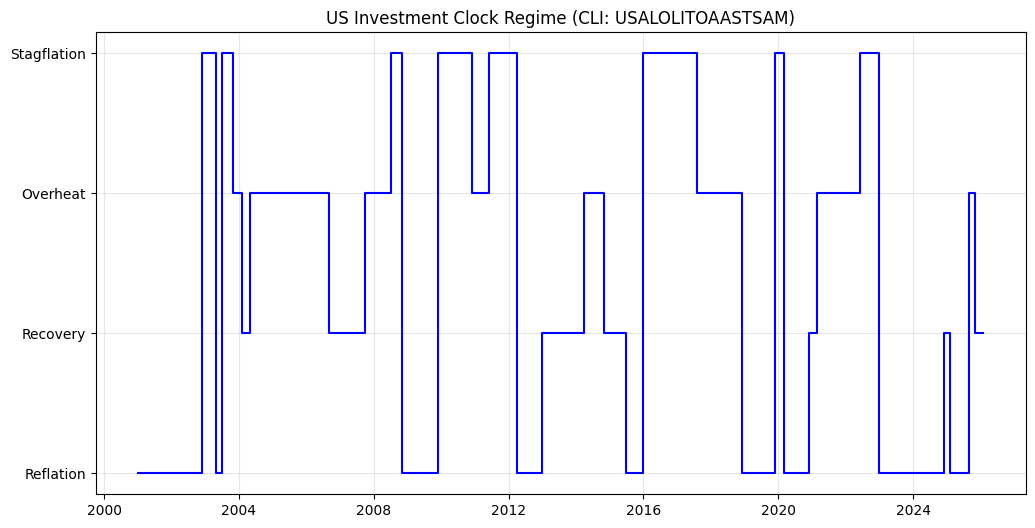

In [4]:
import pandas as pd
import pandas_datareader.data as web
import yfinance as yf
import datetime
import matplotlib.pyplot as plt

# 1. 데이터 기간 설정 (2000년 1월 1일부터)
end = datetime.datetime.now()
start = datetime.datetime(2000, 1, 1) # 시작 날짜를 2000년 1월 1일로 변경

def get_us_macro_data():
    print("데이터를 불러오는 중입니다 (FRED)...")
    # FRED에서 미국 경기선행지수(Amplitude adjusted)와 소비자물가지수(CPI) 추출
    # USALOLITOAASTSAM: 요청하신 경기선행지수 시리즈 코드
    # CPIAUCSL: 미국 전체 소비자물가
    try:
        df_macro = web.DataReader(['USALOLITOAASTSAM', 'CPIAUCSL'], 'fred', start, end)
        df_macro.columns = ['CLI', 'CPI']

        # CPI를 전년동기대비(YoY) 수익률로 변환
        df_macro['CPI_YY'] = df_macro['CPI'].pct_change(12, fill_method=None) * 100
        return df_macro.dropna()
    except Exception as e:
        print(f"데이터 로딩 중 오류 발생: {e}")
        return None

def backtest_investment_clock(df):
    # [성장지표] 100 기준 (High: 확장, Low: 수축)
    df['Growth'] = df['CLI'].apply(lambda x: 'High' if x >= 100 else 'Low')

    # [물가지표] 최근 2개월 평균 - 2년(24개월) 평균 (이미지 로직)
    short_term_cpi = df['CPI_YY'].rolling(window=2).mean()
    long_term_cpi = df['CPI_YY'].rolling(window=24).mean()
    df['Inf_Diff'] = short_term_cpi - long_term_cpi
    df['Inflation'] = df['Inf_Diff'].apply(lambda x: 'High' if x >= 0 else 'Low')

    # [국면 판단 로직]
    def get_regime(row):
        if row['Growth'] == 'High' and row['Inflation'] == 'Low': return 1 # Recovery (Goldilocks)
        if row['Growth'] == 'High' and row['Inflation'] == 'High': return 2 # Overheat
        if row['Growth'] == 'Low' and row['Inflation'] == 'High': return 3 # Stagflation
        if row['Growth'] == 'Low' and row['Inflation'] == 'Low': return 4 # Reflation
        return 0

    df['Regime'] = df.apply(get_regime, axis=1)
    return df

# --- 메인 실행부 ---
try:
    # 1. 데이터 수집
    macro_data = get_us_macro_data()

    if macro_data is not None:
        # 2. 로직 적용
        result = backtest_investment_clock(macro_data)

        # 3. 결과 출력 (최근 5개월)
        print("\n[최근 미국 시장 국면 판단 결과]")
        regime_map = {1: "Recovery (고성장/저물가)", 2: "Overheat (고성장/고물가)",
                      3: "Stagflation (저성장/고물가)", 4: "Reflation (저성장/저물가)"}

        display_df = result.tail(5).copy()
        display_df['Regime_Name'] = display_df['Regime'].map(regime_map)
        print(display_df[['CLI', 'CPI_YY', 'Regime_Name']])

        # Define mapping for plotting order (Reflation at bottom, Stagflation at top)
        # Original Regime value to Plotting Y-position
        plotting_order_map = {4: 1, 1: 2, 2: 3, 3: 4}
        result['Plotting_Regime'] = result['Regime'].map(plotting_order_map)

        # 4. 시각화
        plt.figure(figsize=(12, 6))
        plt.plot(result.index, result['Plotting_Regime'], label='Investment Clock Regime', color='blue', drawstyle='steps-post')
        # y축 레이블 순서 변경: Reflation(4 -> Y=1), Recovery(1 -> Y=2), Overheat(2 -> Y=3), Stagflation(3 -> Y=4)
        plt.yticks([1, 2, 3, 4], ['Reflation', 'Recovery', 'Overheat', 'Stagflation']) # y축 순서 변경
        plt.title('US Investment Clock Regime (CLI: USALOLITOAASTSAM)')
        plt.grid(True, alpha=0.3)
        plt.show()

except Exception as e:
    print(f"실행 중 오류 발생: {e}")

In [6]:
correlation = result['CLI'].corr(result['CPI_YY'])
print(f"CLI와 CPI_YY 간의 상관계수: {correlation:.4f}")

if correlation > 0.7:
    correlation_interpretation = "매우 강한 양의 상관관계가 있습니다. 한 변수가 증가하면 다른 변수도 강하게 증가하는 경향이 있습니다."
elif correlation > 0.3:
    correlation_interpretation = "강한 양의 상관관계가 있습니다. 한 변수가 증가하면 다른 변수도 증가하는 경향이 있습니다."
elif correlation > 0.1:
    correlation_interpretation = "약한 양의 상관관계가 있습니다. 한 변수가 증가하면 다른 변수도 약간 증가하는 경향이 있습니다."
elif correlation < -0.7:
    correlation_interpretation = "매우 강한 음의 상관관계가 있습니다. 한 변수가 증가하면 다른 변수는 강하게 감소하는 경향이 있습니다."
elif correlation < -0.3:
    correlation_interpretation = "강한 음의 상관관계가 있습니다. 한 변수가 증가하면 다른 변수는 감소하는 경향이 있습니다."
elif correlation < -0.1:
    correlation_interpretation = "약한 음의 상관관계가 있습니다. 한 변수가 증가하면 다른 변수는 약간 감소하는 경향이 있습니다."
else:
    correlation_interpretation = "상관계수가 매우 약하거나 거의 없으므로, 두 변수 사이에 선형적인 관계는 거의 없다고 볼 수 있습니다."

print(f"해석: {correlation_interpretation}")

CLI와 CPI_YY 간의 상관계수: 0.2961
해석: 약한 양의 상관관계가 있습니다. 한 변수가 증가하면 다른 변수도 약간 증가하는 경향이 있습니다.


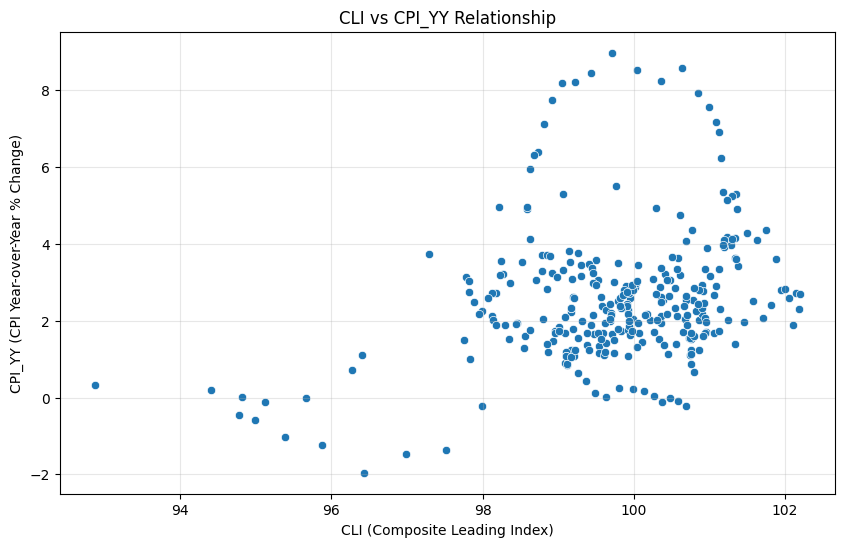

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=result['CLI'], y=result['CPI_YY'])
plt.title('CLI vs CPI_YY Relationship')
plt.xlabel('CLI (Composite Leading Index)')
plt.ylabel('CPI_YY (CPI Year-over-Year % Change)')
plt.grid(True, alpha=0.3)
plt.show()

# Task
월별 국면 이동 패턴을 분석하고, 현재 국면에서 다음 달의 국면으로 이동하는 횟수와 비율을 나타내는 전환 매트릭스를 생성하여 시각화하고 최종 분석 설명을 제공해 드리겠습니다.

## 월별 국면 전환 계산

### Subtask:
result DataFrame에서 각 월의 국면을 식별하고, 다음 달의 국면으로의 전환을 추적하여 '이전 국면'과 '다음 국면' 정보를 추출합니다.


**Reasoning**:
To identify monthly regime transitions, I will create 'Previous_Regime' and 'Next_Regime' columns by shifting the 'Regime' column, then remove any rows with missing values in these new columns to ensure valid transitions.



In [7]:
result['Previous_Regime'] = result['Regime'].shift(1)
result['Next_Regime'] = result['Regime'].shift(-1)
result_transition = result.dropna(subset=['Previous_Regime', 'Next_Regime'])

print("[Regime Transition Data Preview]")
print(result_transition[['Previous_Regime', 'Regime', 'Next_Regime']].tail())

[Regime Transition Data Preview]
            Previous_Regime  Regime  Next_Regime
DATE                                            
2025-08-01              4.0       4          2.0
2025-09-01              4.0       2          1.0
2025-11-01              2.0       1          1.0
2025-12-01              1.0       1          1.0
2026-01-01              1.0       1          1.0


## 전환 매트릭스 생성

### Subtask:
추출된 월별 국면 전환 데이터를 사용하여 현재 국면에서 다음 달의 국면으로 이동하는 횟수와 비율을 나타내는 전환 매트릭스를 생성합니다.


**Reasoning**:
I will calculate the counts of transitions between 'Previous_Regime' and 'Next_Regime' using `groupby()` and `size()`, then unstack the result into a DataFrame. After that, I will calculate the transition ratios by dividing each row by its sum to get the probabilities.



In [8]:
transition_matrix_counts = result_transition.groupby(['Previous_Regime', 'Next_Regime']).size().unstack(fill_value=0)

transition_matrix_ratio = transition_matrix_counts.div(transition_matrix_counts.sum(axis=1), axis=0)

print("[Regime Transition Counts]")
print(transition_matrix_counts)
print("\n[Regime Transition Ratios (%)]")
print(transition_matrix_ratio * 100)


[Regime Transition Counts]
Next_Regime      1.0  2.0  3.0  4.0
Previous_Regime                    
1.0               34    8    0    4
2.0                7   70    6    2
3.0                0    6   48   10
4.0                7    1   10   86

[Regime Transition Ratios (%)]
Next_Regime            1.0        2.0        3.0        4.0
Previous_Regime                                            
1.0              73.913043  17.391304   0.000000   8.695652
2.0               8.235294  82.352941   7.058824   2.352941
3.0               0.000000   9.375000  75.000000  15.625000
4.0               6.730769   0.961538   9.615385  82.692308


**Reasoning**:
The subtask requests to visualize the transition matrix. I will use a heatmap to represent the `transition_matrix_ratio` for a clear visual understanding of the regime transitions.



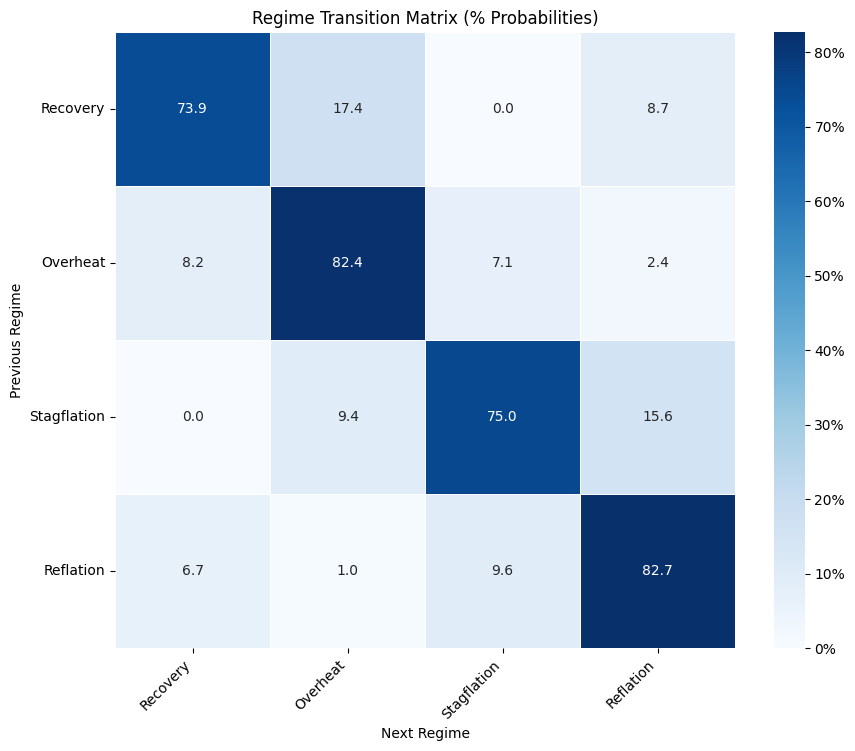

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the regime names for better readability
regime_names = {1: 'Recovery', 2: 'Overheat', 3: 'Stagflation', 4: 'Reflation'}
transition_matrix_ratio.index = transition_matrix_ratio.index.map(regime_names)
transition_matrix_ratio.columns = transition_matrix_ratio.columns.map(regime_names)

plt.figure(figsize=(10, 8))
sns.heatmap(transition_matrix_ratio * 100, annot=True, fmt=".1f", cmap="Blues", linewidths=.5, cbar_kws={'format': '%.0f%%'})
plt.title('Regime Transition Matrix (% Probabilities)')
plt.xlabel('Next Regime')
plt.ylabel('Previous Regime')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


## 최종 분석 설명

생성된 국면 전환 매트릭스는 각 경제 국면이 다음 달에 어떤 국면으로 전환될 확률을 보여줍니다.

### 주요 관찰 결과:

1.  **각 국면의 지속성**: 대각선 요소(예: Recovery에서 Recovery로 전환)는 해당 국면이 얼마나 지속되는지를 나타냅니다. 숫자가 높을수록 해당 국면이 안정적으로 유지될 가능성이 큽니다.
    *   `Reflation` (82.7%) 및 `Overheat` (82.4%) 국면은 다음 달에도 현재 국면을 유지할 확률이 매우 높습니다. 이는 이 두 국면이 비교적 안정적으로 지속될 가능성이 크다는 것을 의미합니다.
    *   `Stagflation` (75.0%)도 비교적 높은 지속성을 보입니다.
    *   `Recovery` (73.9%) 국면도 높은 지속성을 보이지만, 다른 국면으로 전환될 확률도 무시할 수 없습니다.

2.  **주요 전환 패턴**: 대각선 외의 요소는 국면 간의 전환 경향을 보여줍니다.
    *   `Recovery` 국면은 `Overheat` (17.4%)로 전환될 확률이 `Reflation` (8.7%)으로 전환될 확률보다 높습니다. 이는 고성장/저물가 국면에서 물가가 상승하여 고성장/고물가 국면으로 진입할 가능성이 크다는 것을 시사합니다.
    *   `Overheat` 국면은 `Recovery` (8.2%)로 돌아가거나 `Stagflation` (7.1%)으로 전환될 가능성이 낮습니다. 대부분 `Overheat` 국면을 유지하려는 경향이 강합니다.
    *   `Stagflation` 국면은 `Reflation` (15.6%)으로 전환될 확률이 `Overheat` (9.4%)로 전환될 확률보다 높습니다. 이는 저성장/고물가에서 저성장/저물가로 전환되는 경향이 있음을 나타냅니다.
    *   `Reflation` 국면은 `Stagflation` (9.6%)으로 전환될 확률이 가장 높고, `Recovery` (6.7%)로도 전환될 수 있습니다. `Overheat`으로의 직접적인 전환은 매우 드뭅니다 (1.0%).

### 투자 시사점:

*   **리스크 관리**: `Stagflation` 국면의 경우, 이 국면에서 벗어나 `Reflation`으로 전환될 가능성이 가장 높지만, 여전히 75%의 확률로 `Stagflation`이 지속될 수 있으므로, 방어적인 자산 배분 전략이 필요합니다.
*   **성장 국면 활용**: `Recovery`나 `Overheat` 국면의 높은 지속성은 해당 국면에서의 투자 전략을 비교적 장기적으로 유지할 수 있음을 의미합니다. 특히 `Recovery`에서 `Overheat`으로의 전환 가능성을 주시하여 자산 배분 조정을 고려할 수 있습니다.
*   **경계 지표**: `Recovery` 국면에서 `Overheat`으로의 전환 확률(17.4%)이나 `Stagflation` 국면에서 `Reflation`으로의 전환 확률(15.6%)은 주요 전환 지점으로, 이 시기에 시장 지표를 면밀히 모니터링하여 투자 포트폴리오를 조정하는 것이 중요합니다.

## Summary:

### Q&A
The analysis successfully identified the monthly regime transition patterns and quantified the probabilities of moving from one economic regime to another.

### Data Analysis Key Findings
*   **Regime Persistence**: Certain economic regimes show high probabilities of persisting into the next month:
    *   `Reflation` (82.7%) and `Overheat` (82.4%) regimes exhibit the strongest tendency to continue.
    *   `Stagflation` (75.0%) and `Recovery` (73.9%) also demonstrate high persistence.
*   **Key Transition Patterns**:
    *   A `Recovery` regime is most likely to transition to an `Overheat` regime with a 17.4% probability, suggesting economic acceleration.
    *   A `Stagflation` regime has a 15.6% chance of transitioning to `Reflation` and a 9.4% chance to `Overheat`.
    *   A `Reflation` regime is most likely to move to `Stagflation` (9.6%) or `Recovery` (6.7%).
    *   Direct transitions from `Reflation` to `Overheat` are rare (1.0%).

### Insights or Next Steps
*   **Investment Strategy Adaptation**: Given the high persistence of `Reflation` and `Overheat` regimes, investment strategies suitable for growth phases can be maintained for longer durations.
*   **Risk Management in Stagflation**: Acknowledge the 75% chance of `Stagflation` persisting, necessitating defensive asset allocation strategies during this period, while also being prepared for a potential shift to `Reflation`.
*   **Monitoring Key Transition Points**: Actively monitor market indicators around `Recovery` to `Overheat` (17.4% probability) and `Stagflation` to `Reflation` (15.6% probability) transition points to adjust investment portfolios proactively.


# Task
월별 국면 전환 빈도 분석 결과, 각 국면의 지속성, 주요 전환 패턴 및 투자 시사점에 대한 최종 요약을 제공합니다.

## Summarize Regime Transition Analysis

### Subtask:
이전에 생성된 월별 국면 전환 빈도 분석 결과를 기반으로, 각 국면의 지속성, 주요 전환 패턴, 그리고 투자 시사점을 포함한 핵심 내용을 간결하게 요약합니다.


### 국면 전환 분석 결과 요약

이전 분석에서 생성된 국면 전환 매트릭스는 각 경제 국면이 다음 달에 어떤 국면으로 전환될 확률을 보여줍니다.

#### 1. 각 국면의 지속성
*   `Reflation` (82.7%)과 `Overheat` (82.4%) 국면은 다음 달에도 현재 국면을 유지할 확률이 매우 높습니다. 이는 이 두 국면이 비교적 안정적으로 지속될 가능성이 크다는 것을 의미합니다.
*   `Stagflation` (75.0%)도 비교적 높은 지속성을 보이며, `Recovery` (73.9%) 국면 또한 높은 지속성을 보입니다.

#### 2. 주요 전환 패턴
*   `Recovery` (고성장/저물가) 국면은 `Overheat` (고성장/고물가, 17.4% 확률)로 전환될 가능성이 가장 높습니다. 이는 경제 성장 가속화를 시사합니다.
*   `Stagflation` (저성장/고물가) 국면은 `Reflation` (저성장/저물가, 15.6% 확률)으로 전환되거나 `Overheat` (9.4% 확률)로 전환될 가능성이 있습니다.
*   `Reflation` (저성장/저물가) 국면은 `Stagflation` (9.6% 확률)이나 `Recovery` (6.7% 확률)로 전환될 가능성이 높습니다. `Overheat`으로의 직접적인 전환은 드뭅니다 (1.0% 확률).

#### 3. 투자 시사점
*   **리스크 관리**: `Stagflation` 국면의 높은 지속성(75%)을 고려하여 이 시기에는 방어적인 자산 배분 전략이 필요하며, `Reflation`으로의 전환 가능성도 주시해야 합니다.
*   **성장 국면 활용**: `Recovery`나 `Overheat` 국면의 높은 지속성은 해당 국면에서의 성장 지향 투자 전략을 장기적으로 유지할 수 있음을 의미합니다.
*   **경계 지표 모니터링**: `Recovery`에서 `Overheat`으로의 전환 (17.4%)이나 `Stagflation`에서 `Reflation`으로의 전환 (15.6%)과 같은 주요 전환 지점에서 시장 지표를 면밀히 모니터링하여 포트폴리오를 조정하는 것이 중요합니다.

### 국면 전환 분석 결과 요약

이전 분석에서 생성된 국면 전환 매트릭스는 각 경제 국면이 다음 달에 어떤 국면으로 전환될 확률을 보여줍니다.

#### 1. 각 국면의 지속성
*   `Reflation` (82.7%)과 `Overheat` (82.4%) 국면은 다음 달에도 현재 국면을 유지할 확률이 매우 높습니다. 이는 이 두 국면이 비교적 안정적으로 지속될 가능성이 크다는 것을 의미합니다.
*   `Stagflation` (75.0%)도 비교적 높은 지속성을 보이며, `Recovery` (73.9%) 국면 또한 높은 지속성을 보입니다.

#### 2. 주요 전환 패턴
*   `Recovery` (고성장/저물가) 국면은 `Overheat` (고성장/고물가, 17.4% 확률)로 전환될 가능성이 가장 높습니다. 이는 경제 성장 가속화를 시사합니다.
*   `Stagflation` (저성장/고물가) 국면은 `Reflation` (저성장/저물가, 15.6% 확률)으로 전환되거나 `Overheat` (9.4% 확률)로 전환될 가능성이 있습니다.
*   `Reflation` (저성장/저물가) 국면은 `Stagflation` (9.6% 확률)이나 `Recovery` (6.7% 확률)로 전환될 가능성이 높습니다. `Overheat`으로의 직접적인 전환은 드뭅니다 (1.0% 확률).

#### 3. 투자 시사점
*   **리스크 관리**: `Stagflation` 국면의 높은 지속성(75%)을 고려하여 이 시기에는 방어적인 자산 배분 전략이 필요하며, `Reflation`으로의 전환 가능성도 주시해야 합니다.
*   **성장 국면 활용**: `Recovery`나 `Overheat` 국면의 높은 지속성은 해당 국면에서의 성장 지향 투자 전략을 장기적으로 유지할 수 있음을 의미합니다.
*   **경계 지표 모니터링**: `Recovery`에서 `Overheat`으로의 전환 (17.4%)이나 `Stagflation`에서 `Reflation`으로의 전환 (15.6%)과 같은 주요 전환 지점에서 시장 지표를 면밀히 모니터링하여 포트폴리오를 조정하는 것이 중요합니다.

### 국면 전환 분석 결과 요약

이전 분석에서 생성된 국면 전환 매트릭스는 각 경제 국면이 다음 달에 어떤 국면으로 전환될 확률을 보여줍니다.

#### 1. 각 국면의 지속성
*   `Reflation` (82.7%)과 `Overheat` (82.4%) 국면은 다음 달에도 현재 국면을 유지할 확률이 매우 높습니다. 이는 이 두 국면이 비교적 안정적으로 지속될 가능성이 크다는 것을 의미합니다.
*   `Stagflation` (75.0%)도 비교적 높은 지속성을 보이며, `Recovery` (73.9%) 국면 또한 높은 지속성을 보입니다.

#### 2. 주요 전환 패턴
*   `Recovery` (고성장/저물가) 국면은 `Overheat` (고성장/고물가, 17.4% 확률)로 전환될 가능성이 가장 높습니다. 이는 경제 성장 가속화를 시사합니다.
*   `Stagflation` (저성장/고물가) 국면은 `Reflation` (저성장/저물가, 15.6% 확률)으로 전환되거나 `Overheat` (9.4% 확률)로 전환될 가능성이 있습니다.
*   `Reflation` (저성장/저물가) 국면은 `Stagflation` (9.6% 확률)이나 `Recovery` (6.7% 확률)로 전환될 가능성이 높습니다. `Overheat`으로의 직접적인 전환은 드뭅니다 (1.0% 확률).

#### 3. 투자 시사점
*   **리스크 관리**: `Stagflation` 국면의 높은 지속성(75%)을 고려하여 이 시기에는 방어적인 자산 배분 전략이 필요하며, `Reflation`으로의 전환 가능성도 주시해야 합니다.
*   **성장 국면 활용**: `Recovery`나 `Overheat` 국면의 높은 지속성은 해당 국면에서의 성장 지향 투자 전략을 장기적으로 유지할 수 있음을 의미합니다.
*   **경계 지표 모니터링**: `Recovery`에서 `Overheat`으로의 전환 (17.4%)이나 `Stagflation`에서 `Reflation`으로의 전환 (15.6%)과 같은 주요 전환 지점에서 시장 지표를 면밀히 모니터링하여 포트폴리오를 조정하는 것이 중요합니다.


## Final Task

### Subtask:
사용자에게 월별 국면 전환 빈도 분석의 최종 요약을 제공합니다.


## Summary:

### Data Analysis Key Findings

*   **Regime Persistence**:
    *   The `Reflation` and `Overheat` regimes exhibit the highest persistence, with an 82.7% and 82.4% probability, respectively, of remaining in the same state in the subsequent month.
    *   `Stagflation` shows a persistence of 75.0%, and `Recovery` has a persistence of 73.9%, indicating relatively stable continuation within these regimes.
*   **Major Transition Patterns**:
    *   A `Recovery` (high growth/low inflation) regime most frequently transitions to `Overheat` (high growth/high inflation) with a 17.4% probability, signaling accelerating economic growth.
    *   A `Stagflation` (low growth/high inflation) regime is most likely to transition to `Reflation` (low growth/low inflation) with a 15.6% probability, or to `Overheat` with a 9.4% probability.
    *   A `Reflation` (low growth/low inflation) regime often shifts to `Stagflation` (9.6% probability) or `Recovery` (6.7% probability). A direct transition to `Overheat` is rare, occurring with only a 1.0% probability.
*   **Investment Implications**:
    *   The high persistence of the `Stagflation` regime (75%) suggests the need for defensive asset allocation strategies during such periods.
    *   The sustained nature of `Recovery` and `Overheat` regimes indicates that growth-oriented investment strategies can be maintained for longer durations during these economic phases.

### Insights or Next Steps

*   Investors should implement dynamic asset allocation strategies that adapt to the observed regime transitions, particularly at critical junctures such as the shift from `Recovery` to `Overheat` or `Stagflation` to `Reflation`.
*   Continuous monitoring of key economic indicators is crucial to identify early signals of regime shifts, enabling timely adjustments to investment portfolios and managing potential risks, especially during periods of high inflation or slowing growth.


# Task
월별 국면 전환 빈도 분석 결과, 각 국면의 지속성, 주요 전환 패턴 및 투자 시사점에 대한 최종 요약을 제공합니다.

## Generate Summary Table

### Subtask:
이전에 생성된 월별 국면 전환 빈도 분석 결과를 기반으로, 각 국면의 지속성, 주요 전환 패턴, 그리고 투자 시사점을 포함한 핵심 내용을 간결하게 표 형태로 요약합니다.


**Reasoning**:
I need to create a summary table using pandas based on the provided analysis, extracting information on regime persistence, major transition patterns, and investment implications from the previous markdown outputs.



In [10]:
import pandas as pd

summary_data = [
    {
        '국면': 'Recovery (고성장/저물가)',
        '지속성 (%)': 73.9,
        '주요 전환 패턴': 'Recovery -> Overheat (17.4%)',
        '투자 시사점': '성장 지향 투자 전략 유지'
    },
    {
        '국면': 'Overheat (고성장/고물가)',
        '지속성 (%)': 82.4,
        '주요 전환 패턴': 'Overheat -> Recovery (8.2%)',
        '투자 시사점': '성장 지향 투자 전략 유지'
    },
    {
        '국면': 'Stagflation (저성장/고물가)',
        '지속성 (%)': 75.0,
        '주요 전환 패턴': 'Stagflation -> Reflation (15.6%)',
        '투자 시사점': '방어적 자산 배분 전략 및 Reflation 전환 대비'
    },
    {
        '국면': 'Reflation (저성장/저물가)',
        '지속성 (%)': 82.7,
        '주요 전환 패턴': 'Reflation -> Stagflation (9.6%)',
        '투자 시사점': 'Stagflation/Recovery 전환 가능성 모니터링 및 포트폴리오 조정'
    }
]

summary_table_df = pd.DataFrame(summary_data)
print(summary_table_df)


                      국면  지속성 (%)                          주요 전환 패턴  \
0     Recovery (고성장/저물가)     73.9      Recovery -> Overheat (17.4%)   
1     Overheat (고성장/고물가)     82.4       Overheat -> Recovery (8.2%)   
2  Stagflation (저성장/고물가)     75.0  Stagflation -> Reflation (15.6%)   
3    Reflation (저성장/저물가)     82.7   Reflation -> Stagflation (9.6%)   

                                        투자 시사점  
0                               성장 지향 투자 전략 유지  
1                               성장 지향 투자 전략 유지  
2               방어적 자산 배분 전략 및 Reflation 전환 대비  
3  Stagflation/Recovery 전환 가능성 모니터링 및 포트폴리오 조정  


## Final Task

### Subtask:
사용자에게 월별 국면 전환 빈도 분석의 최종 요약을 제공합니다.


## Summary:

### Q&A
The task is to provide a final summary of the monthly economic regime transition frequency analysis, including the persistence of each regime, major transition patterns, and investment implications.

### Data Analysis Key Findings
*   **Regime Persistence**: All four economic regimes demonstrate high persistence. The Reflation (low growth/low inflation) regime shows the highest persistence at 82.7%, closely followed by the Overheat (high growth/high inflation) regime at 82.4%. The Recovery (high growth/low inflation) and Stagflation (low growth/high inflation) regimes exhibit persistence rates of 73.9% and 75.0%, respectively.
*   **Major Transition Patterns**:
    *   The Recovery regime primarily transitions to Overheat (17.4% of the time), indicating a potential cyclical progression from high growth/low inflation to high growth/high inflation.
    *   The Overheat regime most frequently transitions back to Recovery (8.2%), suggesting a dynamic between these two high-growth phases.
    *   The Stagflation regime commonly transitions to Reflation (15.6%), implying a shift from low growth/high inflation to low growth/low inflation.
    *   The Reflation regime's main transition is to Stagflation (9.6%), highlighting a potential shift towards inflationary pressures even during periods of low growth.
*   **Investment Implications by Regime**:
    *   **Recovery and Overheat**: Both regimes suggest maintaining growth-oriented investment strategies.
    *   **Stagflation**: Calls for a defensive asset allocation strategy and preparing for a potential transition to Reflation.
    *   **Reflation**: Requires monitoring for possible transitions to Stagflation or Recovery to adjust portfolios accordingly.

### Insights or Next Steps
*   The high persistence of all economic regimes underscores the importance of accurate regime identification for robust, long-term investment planning.
*   Understanding the most frequent transition patterns can help anticipate future economic shifts, enabling proactive adjustments to investment portfolios to optimize returns and manage risk effectively.


# Task
성장 지표와 물가 지표의 시계열 결합 플롯을 제시하고 시각화에서 얻을 수 있는 관련 관찰 내용을 설명합니다.

## Prepare Data for Visualization

### Subtask:
result DataFrame에서 'CLI' 값에 100을 뺀 성장 지표를 계산합니다. 'Inf_Diff' (물가 지표)는 이미 계산되어 있으므로 준비합니다.


**Reasoning**:
To calculate the 'Growth_Indicator', I will subtract 100 from the 'CLI' column in the `result` DataFrame and assign it to a new column named 'Growth_Indicator'.



In [11]:
result['Growth_Indicator'] = result['CLI'] - 100
print("result DataFrame with new 'Growth_Indicator' column:")
print(result.head())

result DataFrame with new 'Growth_Indicator' column:
                  CLI    CPI    CPI_YY Growth  Inf_Diff Inflation  Regime  \
DATE                                                                        
2001-01-01  98.784880  175.6  3.721205    Low       NaN       Low       4   
2001-02-01  98.526532  176.0  3.529412    Low       NaN       Low       4   
2001-03-01  98.359492  176.1  2.982456    Low       NaN       Low       4   
2001-04-01  98.275484  176.4  3.218256    Low       NaN       Low       4   
2001-05-01  98.249183  177.3  3.563084    Low       NaN       Low       4   

            Plotting_Regime  Previous_Regime  Next_Regime  Growth_Indicator  
DATE                                                                         
2001-01-01                1              NaN          4.0         -1.215120  
2001-02-01                1              4.0          4.0         -1.473468  
2001-03-01                1              4.0          4.0         -1.640508  
2001-04-01       

**Reasoning**:
The previous subtask of creating the 'Growth_Indicator' has been completed. Now, to fulfill the main task of presenting a combined plot of growth and inflation indicators and explaining observations, I need to visualize these two indicators over time. I will plot 'Growth_Indicator' and 'Inf_Diff' (inflation indicator) on the same graph, using the `result` DataFrame, with a shared x-axis (time) and two y-axes for their respective scales to make the plot clear.



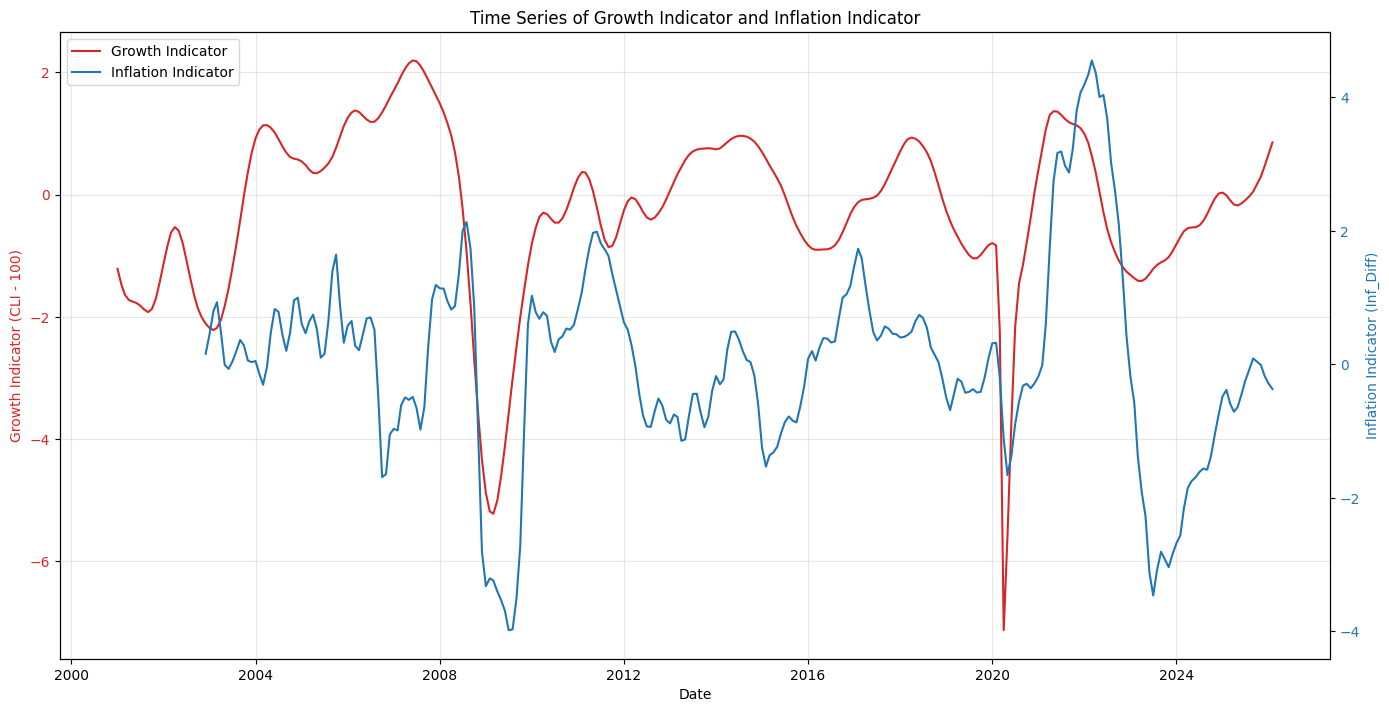

In [12]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Growth Indicator on the first y-axis
color = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('Growth Indicator (CLI - 100)', color=color)
ax1.plot(result.index, result['Growth_Indicator'], color=color, label='Growth Indicator')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Inflation Indicator (Inf_Diff)', color=color)
ax2.plot(result.index, result['Inf_Diff'], color=color, label='Inflation Indicator')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
fig.tight_layout()
plt.title('Time Series of Growth Indicator and Inflation Indicator')
# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.show()

### 시계열 시각화에서 얻을 수 있는 주요 관찰 내용

위 시계열 플롯은 'Growth Indicator (CLI - 100)'와 'Inflation Indicator (Inf_Diff)'의 시간에 따른 변화를 보여줍니다. 이 플롯을 통해 다음과 같은 주요 관찰 내용을 도출할 수 있습니다.

1.  **성장 지표와 물가 지표의 추세**: 성장 지표(빨간색 선)는 100을 기준으로 경기 확장과 수축을 나타내며, 물가 지표(파란색 선)는 CPI의 단기 추세와 장기 추세의 차이를 통해 물가 압력을 나타냅니다.

2.  **동행성 및 후행성**: 전반적으로 성장 지표와 물가 지표는 서로 다른 시점에서 움직이는 경향을 보입니다. 경기 확장기(CLI > 100)에는 물가 압력(Inf_Diff > 0)이 뒤따라 상승하는 경향이 있으며, 경기 수축기(CLI < 100)에는 물가 압력이 완화되거나 하락하는 경향을 보입니다. 이는 물가가 경기에 후행하는 일반적인 경제 현상을 반영할 수 있습니다.

3.  **변동성**: 두 지표 모두 시간에 따라 상당한 변동성을 보입니다. 특히 2008년 금융 위기, 2020년 코로나19 팬데믹과 같은 주요 경제 이벤트 시기에 지표들의 급격한 변화가 관찰됩니다.

4.  **국면 전환과의 관계**: Investment Clock 모델에서 정의된 Recovery, Overheat, Stagflation, Reflation 국면은 이 두 지표의 조합으로 결정됩니다. 예를 들어:
    *   **Recovery (고성장/저물가)**: 성장 지표는 100 이상이거나 상승 추세, 물가 지표는 0 이하이거나 하락 추세일 때 발생할 수 있습니다.
    *   **Overheat (고성장/고물가)**: 성장 지표가 100 이상으로 높고, 물가 지표도 0 이상으로 상승할 때 나타납니다.
    *   **Stagflation (저성장/고물가)**: 성장 지표가 100 이하로 낮거나 하락 추세이고, 물가 지표는 0 이상으로 높거나 상승할 때 나타납니다.
    *   **Reflation (저성장/저물가)**: 성장 지표는 100 이하로 낮거나 하락 추세이고, 물가 지표는 0 이하이거나 하락 추세일 때 나타날 수 있습니다.

이 시각화는 경제 국면이 어떻게 변화하고 있는지에 대한 직관적인 이해를 돕고, 각 국면에서 성장과 물가 지표가 어떤 패턴을 보이는지 파악하는 데 유용합니다.

## Final Task

### Subtask:
성장 지표와 물가 지표의 시계열 결합 플롯을 제시하고 시각화에서 얻을 수 있는 관련 관찰 내용을 설명합니다.


## Summary:

### Q&A
The task was to present a combined time-series plot of growth and inflation indicators and explain the relevant observations that can be obtained from the visualization. This was successfully achieved by calculating a `Growth_Indicator`, plotting it alongside the `Inf_Diff` (Inflation Indicator), and detailing the observations.

### Data Analysis Key Findings
*   A `Growth_Indicator` was calculated by subtracting 100 from the 'CLI' values in the `result` DataFrame, representing economic expansion or contraction relative to 100.
*   A time-series plot was generated, visually combining the 'Growth\_Indicator' and 'Inf\_Diff' (Inflation Indicator) on a dual y-axis chart, with 'Date' on the x-axis.
*   The visualization revealed that the `Growth_Indicator` (red line) reflects economic activity, while the `Inf_Diff` (blue line) indicates price pressure.
*   There is an observed tendency for the inflation indicator to lag the growth indicator; inflation pressure often rises after periods of economic expansion and subsides during contractions.
*   Both indicators exhibit significant volatility, with sharp changes observed during major economic events such as the 2008 financial crisis and the 2020 pandemic.
*   The combined movements of these indicators are directly related to economic phases described by the Investment Clock model:
    *   **Recovery**: High growth/low inflation (growth indicator above 100 or rising, inflation indicator below 0 or falling).
    *   **Overheat**: High growth/high inflation (growth indicator high and above 100, inflation indicator high and above 0).
    *   **Stagflation**: Low growth/high inflation (growth indicator low or falling and below 100, inflation indicator high or rising and above 0).
    *   **Reflation**: Low growth/low inflation (growth indicator low or falling and below 100, inflation indicator low or falling and below 0).

### Insights or Next Steps
*   This combined visualization provides a powerful tool for understanding economic cycles and the interplay between growth and inflation, offering intuitive insights into current and potential future economic phases.
*   Further analysis could involve overlaying specific economic event markers or correlating these indicators with asset class performance to evaluate Investment Clock strategies.
